<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  /></center>
  


## Lab: Advanced Data Augmentation with Keras 


##### Estimated time needed:  30 minutes


You will learn to implement and experiment with various data augmentation techniques using Keras in this lab. 

#### Learning objectives 

By the end of this lab, you will: 

- Implement various data augmentation techniques using Keras 
- Implement feature-wise and sample-wise normalization on the data set. 
- Define and apply a custom augmentation function that adds random noise to images. 
- Display the augmented images to understand the effect of different augmentation techniques.  


#### Step-by-step instructions 

##### Step 1: Setup the environment 

First, you need to import the necessary libraries and load the data set as follows: 


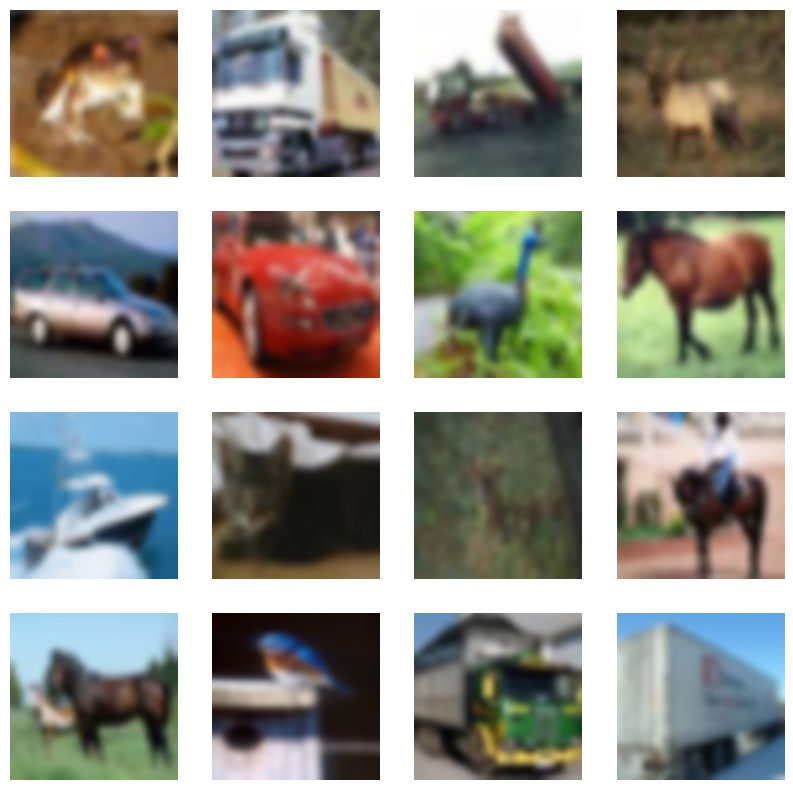

In [3]:
# Import necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load CIFAR-10 dataset for training images
import os
import pickle

def load_local_data(folder_path):
    def unpickle(file):
        with open(file, 'rb') as fo:
            return pickle.load(fo, encoding='bytes')
    
    # Load 5 file train
    x_train = []
    y_train = []
    for i in range(1, 6):
        batch = unpickle(os.path.join(folder_path, f'data_batch_{i}'))
        x_train.append(batch[b'data'])
        y_train.append(batch[b'labels'])
    
    # Gộp và định dạng lại ảnh (Số lượng, Cao, Rộng, Kênh màu)
    x_train = np.concatenate(x_train).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_train = np.concatenate(y_train).reshape(-1, 1)
    
    # Load file test
    test_batch = unpickle(os.path.join(folder_path, 'test_batch'))
    x_test = test_batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_test = np.array(test_batch[b'labels']).reshape(-1, 1)
    
    return (x_train, y_train), (x_test, y_test)

path = "cifar-10-batches-py"
(x_train, y_train), (x_test, y_test) = load_local_data(path)

# Normalize the pixel values for augmentation
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Display a sample of the training images
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_train[i], interpolation='bicubic')
    plt.axis('off')
plt.show()


### **Create sample.jpg for the Lab**


In [4]:
from PIL import Image, ImageDraw

# Create a blank white image
image = Image.new('RGB', (224, 224), color = (255, 255, 255))

# Draw a red square
draw = ImageDraw.Draw(image)
draw.rectangle([(50, 50), (174, 174)], fill=(255, 0, 0))

# Save the image
image.save('sample.jpg')


In [5]:
import numpy as np 
import matplotlib.pyplot as plt 
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array 

# Load a sample image 
img_path = 'sample.jpg' 
img = load_img(img_path) 
x = img_to_array(img) 
x = np.expand_dims(x, axis=0) 

In the code: 
- `!pip install tensorflow==2.16.2 matplotlib==3.9.1` installs the specified versions of `TensorFlow and Matplotlib`.  

- `tensorflow` is the main library for machine learning in Python.  

- `Model` is used to create a model with the Functional API. 

- `Input` and ‘Dense’ are types of layers that you will use in your model.  


#### Step 2: Basic data augmentation 

Apply basic augmentations such as rotation, width shift, height shift, shear, zoom, and horizontal flip using the ImageDataGenerator as follows:


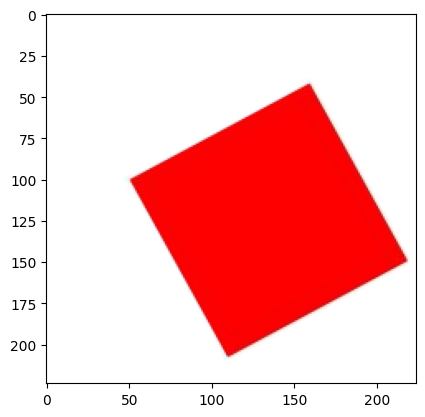

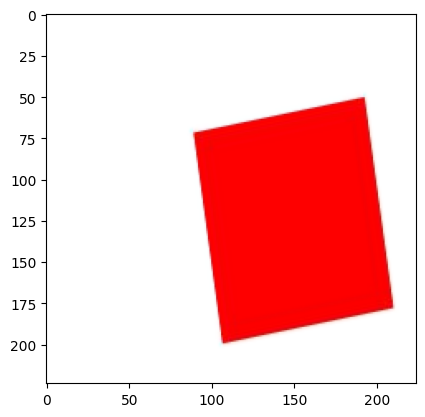

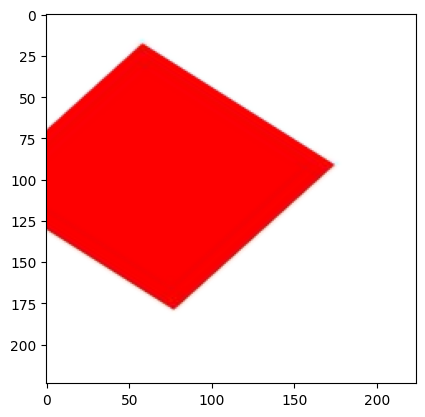

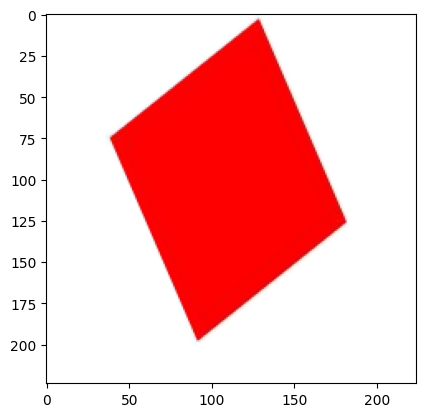

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Load the sample image
img_path = 'sample.jpg'
img = load_img(img_path)
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

# Create an instance of ImageDataGenerator with basic augmentations
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generate batches of augmented images
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()



#### Step 3: Feature-wise and sample-wise normalization 

Implement feature-wise and sample-wise normalization on the data set as follows:    


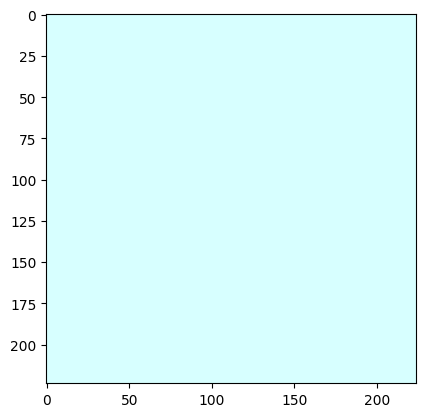

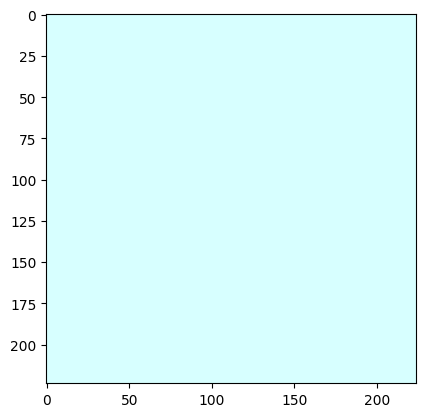

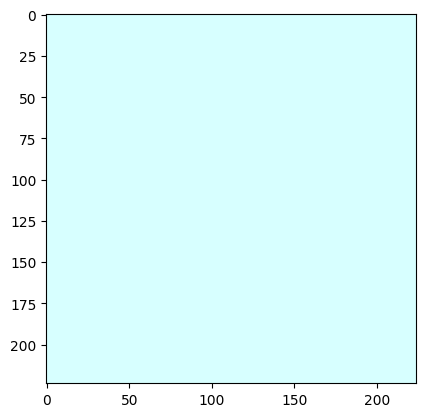

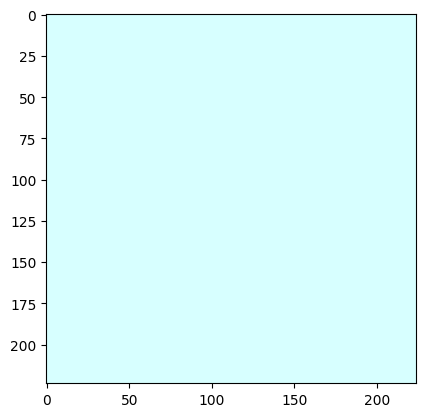

In [7]:
# Create an instance of ImageDataGenerator with normalization options
datagen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    samplewise_center=True,
    samplewise_std_normalization=True
)

# Load the sample image again and fit the generator (normally done on the training set)
datagen.fit(x)

# Generate batches of normalized images
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()




#### Step 4: Custom data augmentation function 

Next, you define and apply a custom augmentation function that adds random noise to images as follows: 


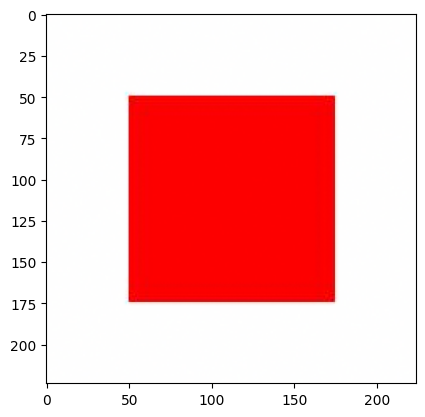

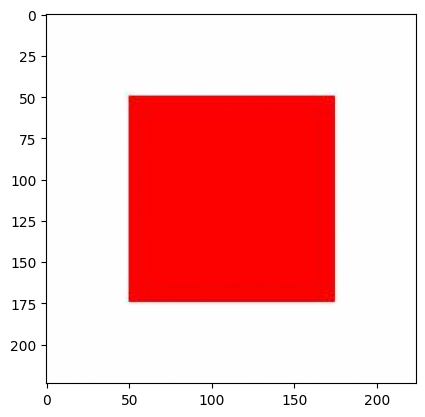

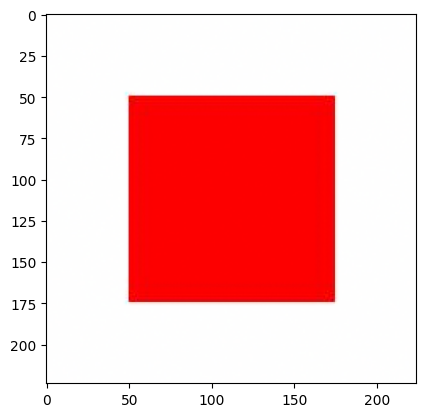

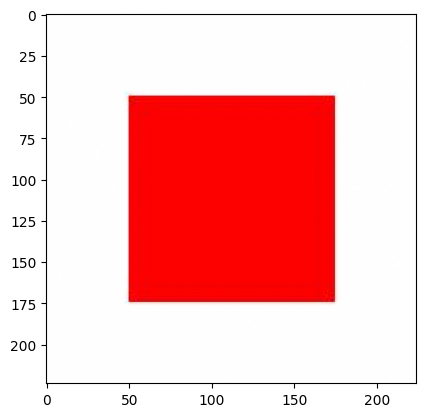

In [8]:
# Define a custom data augmentation function
def add_random_noise(image):
    noise = np.random.normal(0, 0.1, image.shape)
    return image + noise

# Create an instance of ImageDataGenerator with the custom augmentation
datagen = ImageDataGenerator(preprocessing_function=add_random_noise)

# Generate batches of augmented images with noise
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()

#### Step 5: Visualize augmented images 

Visualize the augmented images to understand the impact of each augmentation technique. 


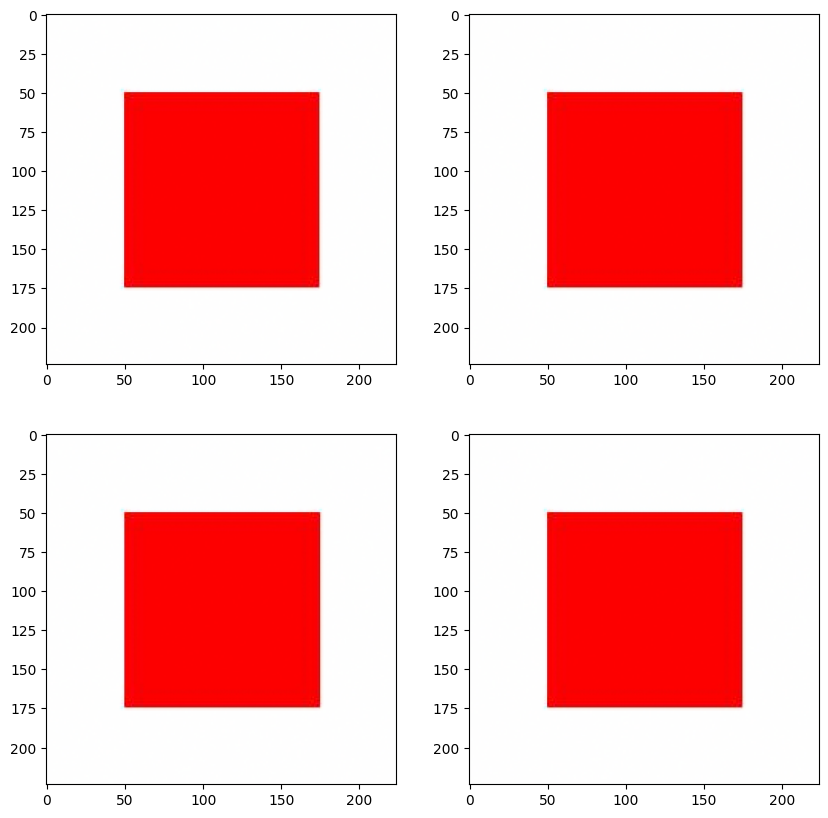

In [9]:
# Visualizing multiple augmented versions of the same image
plt.figure(figsize=(10, 10))
for i, batch in enumerate(datagen.flow(x, batch_size=1)):
    if i >= 4:  # Show only 4 versions
        break
    plt.subplot(2, 2, i+1)
    plt.imshow(batch[0].astype('uint8'))
plt.show()



This Markdown explanation will provide clarity in a Jupyter Notebook, making the code and its purpose easier to understand.


## Practice Exercises:


### Exercise 1: Apply and Visualize Different Augmentation Techniques 

  

Objective: Experiment with different augmentation techniques and visualize their effects. 


Download the `sample_images` folder containing a collection of images that will be used for this practice exercise.


### Instructions: 

1. Create an instance of `ImageDataGenerator` with various augmentations such as rotation, width shift, height shift, shear, zoom, and horizontal flip. 

2. Generate and visualize augmented images. 


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img  

import matplotlib.pyplot as plt  

import numpy as np  

 

# Define the augmentation parameters  

datagen = ImageDataGenerator(  

    rotation_range=40,  

    width_shift_range=0.2,  

    height_shift_range=0.2,  

    shear_range=0.2,  

    zoom_range=0.2,  

    horizontal_flip=True,  

    fill_mode='nearest'  

)  

 

# Load and preprocess the dataset  

image_paths = [  

    'sample_images/training_images1.jpg',  

    'sample_images/training_images2.jpg',  

    'sample_images/training_images3.jpg'  

]  

 

training_images = []  

for image_path in image_paths:  

    img = load_img(image_path, target_size=(224, 224))  

    img_array = img_to_array(img)  

    training_images.append(img_array)  

training_images = np.array(training_images)  

 

# Generate and visualize augmented images  

i = 0  

for batch in datagen.flow(training_images, batch_size=1):  

    plt.figure(i)  

    imgplot = plt.imshow(array_to_img(batch[0]))  

    plt.title(f'Augmented Image {i + 1}')  

    i += 1  

    if i % 4 == 0:  

        break  

plt.show()

### Exercise 2: Implement Feature-wise and Sample-wise Normalization
 
Objective: Apply feature-wise and sample-wise normalization to the dataset.
 
Instructions:
1. Create an instance of `ImageDataGenerator` with feature-wise and sample-wise normalization.
2. Fit the `ImageDataGenerator` to the data set and visualize the normalized images.


In [ ]:
# Create an instance of ImageDataGenerator with normalization options  

datagen = ImageDataGenerator(  

    featurewise_center=True,  

    featurewise_std_normalization=True,  

    samplewise_center=True,  

    samplewise_std_normalization=True  

)  

### Exercise 3: Create and Apply a Custom Data Augmentation Function
 
Objective: Define a custom data augmentation function that adds random noise to images and apply it.
 
Instructions:
1. Define a function that adds random noise to an image.
2. Create an instance of `ImageDataGenerator` with the custom augmentation function.
3. Generate and visualize augmented images.


In [ ]:
 # Define a custom augmentation function to add random noise  

def add_random_noise(image):  

    noise = np.random.normal(0, 0.1, image.shape)  

    return image + noise  

 

# Create an instance of ImageDataGenerator with custom augmentation  

datagen = ImageDataGenerator(preprocessing_function=add_random_noise)  

 

# Generate and visualize augmented images  

i = 0  

for batch in datagen.flow(training_images, batch_size=1):  

    plt.figure(i)  

    imgplot = plt.imshow(array_to_img(batch[0]))  

    plt.title(f'Noisy Image {i + 1}')  

    i += 1  

    if i % 4 == 0:  

        break  

plt.show()